# 02. 確率分布とシミュレーション — ベイズの部品箱

## この章で分かること

- ベイズ推定に頻出する 7 つの分布の **役割**(何の事前/尤度になるか)
- パラメータが形をどう変えるか(スライダーで体感)
- サンプル数を増やすとヒストグラムが理論分布に近づくこと(大数の法則)
- **ベータ分布** — 本書で最も重要な分布

分布は暗記対象ではなく「部品」です。各分布を **どのフローのどこで使うか** で覚えます。

| 分布 | 主な役割 |
|---|---|
| ベルヌーイ / 二項 | 成功・失敗データの **尤度** |
| ベータ | 確率 $\theta \in [0,1]$ の **事前/事後** |
| ポアソン | カウントデータの **尤度** |
| ガンマ | 正の量(レート $\lambda$)の **事前/事後** |
| 正規 | 連続値の **尤度** にも **事前/事後** にも |
| ディリクレ | 確率ベクトル(多カテゴリ)の **事前/事後** |

```{admonition} 核心 — ひとことで
:class: tip
**確率分布は暗記対象ではなく「部品」。尤度になる分布とパラメータの信念を表す分布を、フローのどこで使うかで覚える。**
主役は **ベータ分布＝確率の確率**：$\mathrm{Beta}(\alpha,\beta)$ は「$\alpha-1$ 回の成功と $\beta-1$ 回の失敗をすでに見た」信念。
尤度と事前を**共役ペア**で合わせると事後が同じ族に閉じ、紙と鉛筆で解ける（次章）。
```

In [1]:
# Shared setup.
import matplotlib.pyplot as plt
import numpy as np
import plotly.io as pio
from scipy import stats

from bayes_textbook import visualization as viz
from bayes_textbook.distributions import grid_pdf, sample_dirichlet, simplex_to_xy

pio.renderers.default = "plotly_mimetype+notebook_connected"
rng = np.random.default_rng(42)
np.set_printoptions(precision=3, suppress=True)

## 1. 離散分布 — ベルヌーイ・二項・ポアソン

- **ベルヌーイ** $\mathrm{Bern}(p)$: 1 回の成功/失敗。
- **二項** $\mathrm{Bin}(n, p)$: $n$ 回中の成功数。ベルヌーイの和。
- **ポアソン** $\mathrm{Pois}(\lambda)$: 単位時間あたりの発生数(到着・事故・アクセス)。
  平均と分散がどちらも $\lambda$ になるのが特徴。

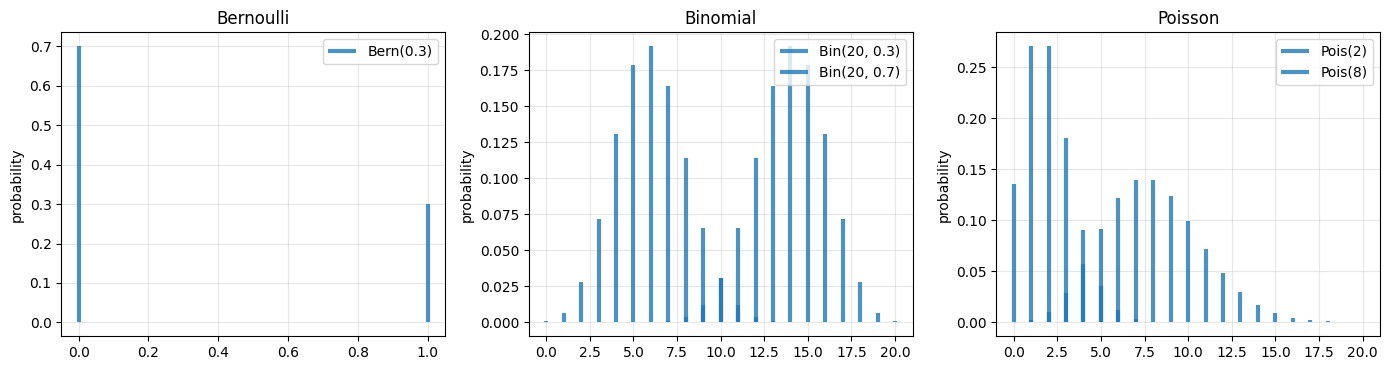

In [2]:
# The three discrete workhorses.
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
viz.plot_distribution(stats.bernoulli(0.3), kind="discrete", ax=axes[0], label="Bern(0.3)")
for n, p in [(20, 0.3), (20, 0.7)]:
    viz.plot_distribution(stats.binom(n, p), kind="discrete", ax=axes[1], label=f"Bin({n}, {p})")
for lam in [2, 8]:
    viz.plot_distribution(stats.poisson(lam), kind="discrete", ax=axes[2], label=f"Pois({lam})")
for ax, t in zip(axes, ["Bernoulli", "Binomial", "Poisson"], strict=True):
    ax.set_title(t)
plt.tight_layout()
plt.show()

## 2. ベータ分布 — 「確率の確率」

$\mathrm{Beta}(\alpha, \beta)$ は $[0, 1]$ 上の分布で、**確率そのものの不確実性** を表します。
本書の主役です。覚え方はひとつだけ:

> $\alpha - 1$ 回の成功と $\beta - 1$ 回の失敗を「すでに見た」状態の信念

- $\mathrm{Beta}(1,1)$ = 一様(何も知らない)
- $\alpha, \beta$ を大きく = 確信が強い(分布が尖る)
- $\alpha/(\alpha+\beta)$ = 平均(成功率の見込み)

下の Plotly スライダーで形の変化を体感してください(静的 HTML でも動きます)。

In [3]:
# Beta distribution shapes: slider over (alpha, beta) pairs.
theta = np.linspace(0.001, 0.999, 300)
frames = []
for a, b in [(1, 1), (0.5, 0.5), (2, 2), (5, 2), (2, 5), (20, 20), (50, 10)]:
    frames.append((f"a={a}, b={b}",
                   [(f"Beta({a},{b})", stats.beta(a, b).pdf(theta), None)]))
fig = viz.plotly_curve_slider(theta, frames, slider_name="params",
                              title="Beta(alpha, beta): the distribution OF a probability")
fig.update_xaxes(title="theta")
fig.update_yaxes(title="density")
fig.show()

## 3. 連続分布 — 正規・ガンマ

- **正規** $\mathcal{N}(\mu, \sigma^2)$: 連続値の万能選手。和・平均が正規に近づく(中心極限定理)。
- **ガンマ** $\mathrm{Gamma}(\alpha, \beta)$: 正の量の分布。ポアソンのレート $\lambda$ の事前分布として
  04 章で活躍(本書は shape–**rate** パラメータ化)。

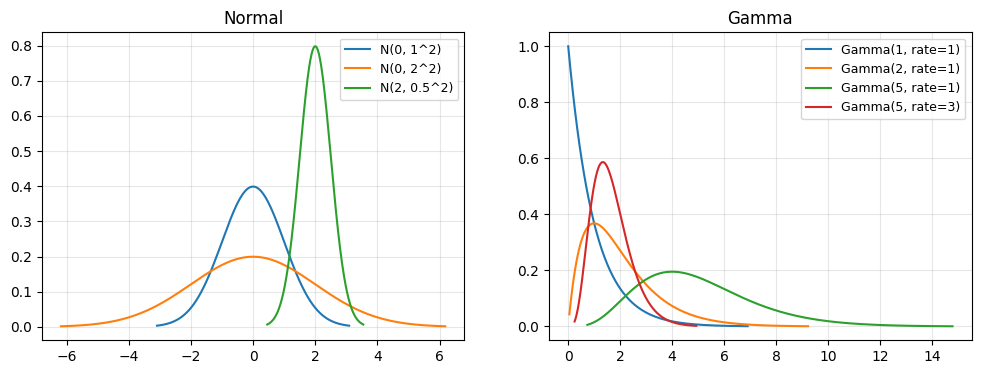

In [4]:
# Normal and Gamma families.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for mu, sd in [(0, 1), (0, 2), (2, 0.5)]:
    x, y = grid_pdf(stats.norm(mu, sd))
    axes[0].plot(x, y, label=f"N({mu}, {sd}^2)")
for shape, rate in [(1, 1), (2, 1), (5, 1), (5, 3)]:
    x, y = grid_pdf(stats.gamma(shape, scale=1 / rate))
    axes[1].plot(x, y, label=f"Gamma({shape}, rate={rate})")
for ax, t in zip(axes, ["Normal", "Gamma"], strict=True):
    ax.set_title(t); ax.grid(alpha=0.3); ax.legend(fontsize=9)
plt.show()

## 4. ディリクレ分布 — 確率ベクトルの分布

ベータ分布の多次元版。$K$ 個のカテゴリの確率 $(p_1, \dots, p_K)$(合計 1)に対する分布です。
$K=3$ なら確率ベクトルは三角形(単体)の上に住むので、サンプルを三角形に描けます。

- $\alpha = (1,1,1)$: 三角形上で一様
- $\alpha$ を大きく: 中心(均等な確率)に集中
- $\alpha$ を小さく: 角(どれか 1 カテゴリに偏る)に集中

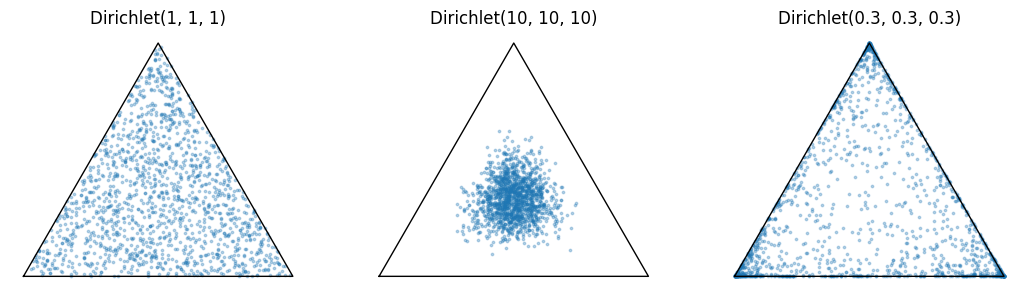

In [5]:
# Dirichlet samples on the 3-simplex for different concentration parameters.
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
corners = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3) / 2], [0, 0]])
for ax, alpha in zip(axes, [(1, 1, 1), (10, 10, 10), (0.3, 0.3, 0.3)], strict=True):
    pts = sample_dirichlet(alpha, n=1500, seed=0)
    x, y = simplex_to_xy(pts)
    ax.plot(corners[:, 0], corners[:, 1], "k-", lw=1)
    ax.scatter(x, y, s=3, alpha=0.3)
    ax.set_title(f"Dirichlet{alpha}")
    ax.set_aspect("equal"); ax.axis("off")
plt.show()

## 5. シミュレーション — ヒストグラムは理論分布に近づく

「分布からサンプルを引く」ことと「理論曲線」の関係を体感します。
サンプル数 $n$ を増やすほどヒストグラムは pdf に張り付いていきます(大数の法則)。

In [6]:
# Histogram -> pdf as n grows (law of large numbers in action).
frames = []
x_grid = np.linspace(-4, 4, 200)
pdf = stats.norm.pdf(x_grid)
for n in [30, 100, 1000, 10000, 100000]:
    samples = np.random.default_rng(0).standard_normal(n)
    hist, edges = np.histogram(samples, bins=40, range=(-4, 4), density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    # Build step-like curve from the histogram for the slider frames.
    frames.append((f"{n:,}",
                   [("histogram", np.interp(x_grid, centers, hist), None),
                    ("true pdf", pdf, "dash")]))
fig = viz.plotly_curve_slider(x_grid, frames, slider_name="n samples",
                              title="sampling converges to the theoretical density")
fig.show()

### インタラクティブ(JupyterLab のみ)

ドロップダウンで分布を選び、パラメータをスライダーで動かす探索ツールです。

In [7]:
# Interactive (JupyterLab only): distribution explorer with parameter sliders.
from bayes_textbook.widgets import interactive_distribution

interactive_distribution()

(Dropdown(description='dist', index=3, options=('bernoulli', 'binomial', 'poisson', 'beta', 'normal', 'gamma'), value='beta'),
 Output())

## 6. 分布同士のつながり(予告)

03〜04 章で使う「共役ペア」の地図です。**左の尤度に右の事前を合わせると、事後も右の族に残る**:

| 尤度(データ) | 事前/事後(パラメータ) |
|---|---|
| ベルヌーイ / 二項 | ベータ |
| ポアソン | ガンマ |
| 正規(分散既知) | 正規 |
| 多項 | ディリクレ |

この「閉じる」性質のおかげで、事後分布が紙と鉛筆で書けます。次章でフルに使います。

## 7. まとめ

- 分布は「部品」: 尤度になる分布(ベルヌーイ・二項・ポアソン・正規)と、
  パラメータの信念を表す分布(ベータ・ガンマ・正規・ディリクレ)。
- **ベータ分布 = 確率の確率**。$\alpha, \beta$ は「すでに見た成功・失敗数」と読む。
- サンプリングと理論分布は大数の法則でつながる — シミュレーションは常に検算に使える。
- 共役ペア(尤度 × 事前)が次章からの主役。

## 8. Exercises

1. $\mathrm{Bin}(50, 0.3)$ の平均と分散を式($np$, $np(1-p)$)で計算し、
   10 万サンプルの標本平均・分散と照合せよ。
2. $\mathrm{Beta}(\alpha, \beta)$ の平均 $\alpha/(\alpha+\beta)$ を、
   (2,2)・(8,2)・(80,20) で計算し、分布の尖り方と合わせて解釈せよ。
3. ポアソンの「平均=分散」をシミュレーションで確認せよ($\lambda = 7$)。
4. $\mathrm{Gamma}(\text{shape}=a, \text{rate}=b)$ の平均は $a/b$。
   scipy の `scale` パラメータとの関係($\text{scale} = 1/b$)に注意して確認せよ。
5. Dirichlet(5, 1, 1) のサンプルを単体に描き、どの角に集中するか確認せよ。
6. (発展)二項分布で $n$ を大きくしながら標準化すると正規分布に近づくこと
   (中心極限定理)をヒストグラムで示せ。

```{admonition} 実社会では
:class: important
「どの分布を部品に選ぶか」がモデリングの第一歩です。

- 成功/失敗（CVR・歩留まり）→ 二項＋ベータ、到着・件数（アクセス・故障）→ ポアソン＋ガンマ。
- 連続値（売上・測定）→ 正規、多カテゴリ（シェア・トピック）→ 多項＋ディリクレ。
- シミュレーション（大数の法則）は、解析解の検算にも、複雑モデルの近似計算にも常用。
```